# 🫁 CXR DenseNet121 — **v3 PESADO** (CPU · máximo nivel · modelo independiente)
## TFM · Módulo Imagen (Radiografía de tórax) · Universidad de Salamanca

---

Versión más exigente del módulo de imagen: **ensemble de dos backbones** (DenseNet-121@224 con
**TTA por flip** + ResNet-50@512), cabeza MLP sobre embeddings concatenados con metadatos clínicos,
**K-fold con bagging multisemilla**. Diseñada para < 24 h en CPU.

## 🔄 Adaptación a las conclusiones del EDA

| Cambio | Detalle | Origen (recuadro naranja) |
|---|---|---|
| **Etiquetado FINAL** | `POS=(==1)` · `NEG=(==0)|(NaN→0)` · **−1 ENMASCARADO** (U-Ignore). **Se elimina** la derivación de negativos desde *No Finding*. | §3 Definición del negativo |
| **Métrica primaria = AUC-PR** | `macro_AP_path` en K-fold, selección e informes; **AUC-ROC secundaria**; **IC bootstrap** de AP y AUC. | §3 Métrica · §1 IC |
| **Puntos de operación** | F1, **cribado (Se≥0,90)** y **confirmación (Sp≥0,90)** fijados en VAL, con **Se/Sp/VPP/VPN**. | §11 Puntos de operación |
| **Calibración verificada** | **Brier** antes/después + curva de fiabilidad. | §11 Calibración |
| **Pre-registro** | Regla de decisión congelada en JSON **antes** de tocar test. | §11 Protocolo |
| **Control de calidad de imagen** | Chequeo de contraste mínimo (std de píxel) antes de extraer embeddings. | Anexo EDA (señal de imagen) |
| **Equidad y robustez** | Estratificación por sexo, etnia, ingreso y **proyección AP/PA**. | §2/§9 · Anexo CXR |

### ⚠️ `cxr_view` retirada de los metadatos (cambio de criterio)
Antes entraba como **variable predictora** en la rama de metadatos (`META_DIM` era 18). **Ya no.**
La proyección AP se hace al paciente encamado, así que es un **proxy de gravedad**, no señal
biológica: incluirla dejaba al modelo aprender el atajo *"placa portátil ⇒ paciente grave"* e
inflaba el resultado. Además **la propia imagen ya contiene la proyección**, con lo que era
redundante para el backbone. `META_DIM` baja de 18 a **16**.

> Se conserva **solo como eje de estratificación** en la evaluación — la rama *"monitorizar su
> efecto en Cardiomegalia"* del anexo del EDA.

### Sobre el preprocesado de imagen
Se usa el pipeline de **`torchxrayvision`** (1 canal, rango [−1024, 1024]). Los `.npy` vienen
z-scored estilo ImageNet y se convierten con un min-max por imagen. **No se toca**: es el rango que
exige este backbone, y alterarlo rompería el modelo.

- **B5 y B7 no aplican**: sin variables tabulares ni *missingness* que vigilar. → §6

> **Aviso:** los resultados **no son comparables** con los de la ejecución previa (otro etiquetado,
> otra métrica y `cxr_view` ya no entra como predictor).



In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try: import torch  # noqa
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch","--index-url","https://download.pytorch.org/whl/cpu","-q"],check=True)
for p in ["torchxrayvision","scikit-learn","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q"],check=False)
print("Dependencias listas.")

Dependencias listas.


In [2]:
# CELDA 2 · IMPORTS, RUTAS Y CONSTANTES
import os, gc, json, time, copy, random, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchxrayvision as xrv
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4); DEVICE=torch.device("cpu")

BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV=BASE/"data_csv"/"clean"; NPY=BASE/"data_npy"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV/"train_clean.csv",CSV/"val_clean.csv",CSV/"test_clean.csv"
CXR_NPY={"train":NPY/"train"/"cxr_train.npy","val":NPY/"val"/"cxr_val.npy","test":NPY/"test"/"cxr_test.npy"}
HADM_NPY={"train":NPY/"train"/"hadm_id_train.npy","val":NPY/"val"/"hadm_id_val.npy","test":NPY/"test"/"hadm_id_test.npy"}
DENSE_CACHE=Path(r"C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\salidas\01_cxr\v2")/"embeddings"      # embeddings DenseNet@224 ya cacheados por el v2
OUTPUT_DIR=Path(r"C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\salidas\01_cxr\v3"); OUTPUT_DIR.mkdir(exist_ok=True)
EMB_DIR=OUTPUT_DIR/"embeddings"; EMB_DIR.mkdir(exist_ok=True); FIG=OUTPUT_DIR/"figuras"; FIG.mkdir(exist_ok=True)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY=[l for l in LABELS if l!=NO_FINDING]; CORE=["Cardiomegaly","Edema","Pleural Effusion"]
XRV_RANGE=1024.0; EMB_BATCH=16
DENSE_W="densenet121-res224-all"; DENSE_SIZE=224
RESNET_W="resnet50-res512-all"; RESNET_SIZE=512
USE_TTA=True; USE_RESNET=True               # pon USE_RESNET=False para acortar (~horas menos)
K_FOLDS=5; BAG_SEEDS=[42,1,7]               # bagging multisemilla de la cabeza
EPOCHS,PATIENCE=40,6
# metadatos (18 dims)
GENDER={0:0,1:1,"0":0,"1":1,"M":1,"F":0}; RACE={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADM={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}; LOC={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
VIEW={"AP":0,"PA":1}   # solo para estratificar en la evaluacion, NUNCA como predictor
META_DIM=1+1+5+4+4+1   # = 16 (antes 18: se quito cxr_view, proxy de gravedad)
print("Salidas en", OUTPUT_DIR, "· USE_TTA", USE_TTA, "· USE_RESNET", USE_RESNET)


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Salidas en outputs_cxr_densenet121_v3 · USE_TTA True · USE_RESNET True


In [3]:
# CELDA 3 · CARGA Y ALINEACIÓN CSV <-> imagen (join por hadm_id; .npy mapeado en disco)
def load_split(csv,cxr_npy,hadm,name):
    df=pd.read_csv(csv,sep=";"); h=np.load(hadm,allow_pickle=True); h2i={int(x):i for i,x in enumerate(h)}
    df["_npy_idx"]=df["hadm_id"].map(lambda z:h2i.get(int(z),-1)); n0=len(df)
    df=df[df["_npy_idx"]>=0].reset_index(drop=True); a=np.load(cxr_npy,mmap_mode="r")
    print(f"{name:5s}: CSV={n0:,} con imagen={len(df):,} · {a.shape}"); return df,a
df_train,cxr_train=load_split(TRAIN_CSV,CXR_NPY["train"],HADM_NPY["train"],"train")
df_val,cxr_val=load_split(VAL_CSV,CXR_NPY["val"],HADM_NPY["val"],"val")
df_test,cxr_test=load_split(TEST_CSV,CXR_NPY["test"],HADM_NPY["test"],"test")

train: CSV=10,000 con imagen=10,000 · (10000, 3, 320, 320)
val  : CSV=750 con imagen=750 · (750, 3, 320, 320)
test : CSV=464 con imagen=464 · (4640, 3, 320, 320)


In [ ]:
# CELDA 4 · OBJETIVOS (definición FINAL del negativo) y METADATOS
# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · build_targets
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : convierte los cuatro estados de cada etiqueta (1 / 0 / −1 / NaN) en `labels` (0-1)
#              y `mask` (1 = cuenta en pérdida y métrica, 0 = se ignora).
# POR QUÉ    : fija la definición FINAL del negativo acordada con el tutor, IDÉNTICA en las tres
#              modalidades — requisito para que la fusión combine probabilidades coherentes.
#              POS = (==1) · NEG = (==0) | (NaN→0) · −1 = ENMASCARADO (U-Ignore de CheXpert).
# ENTRADAS   : df (split) · uncertainty_policy ("ignore") · derive (compatibilidad) · verbose
# SALIDAS    : (labels (N,6) float32, mask (N,6) float32)
# ORIGEN EDA : §3 · "negativo = 0 explícito + NaN→0; el −1 se enmascara; «Sin hallazgo» NO como
#              negativo (evita el sesgo de espectro)".
# CAMBIO vs versión previa: se ELIMINA la derivación de negativos desde «No Finding»; el NaN pasa a
#              NEGATIVO con máscara activa en lugar de quedar enmascarado.
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              verificar pos_weight ≈ 2,28/1,85/3,43/2,15/6,31/1,66 en train; las métricas NO son
#              comparables con las de la ejecución anterior.
# ══════════════════════════════════════════════════════════════════════════════
def build_targets(df, uncertainty_policy="ignore", derive=False, verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=(raw==1.0).astype(np.float32)          # 1 → positivo ; 0 y NaN → 0 (negativo)
    mask  =np.ones((N,N_LABELS),np.float32)       # por defecto TODO entra en pérdida/métrica
    unc=(raw==-1.0)
    if   uncertainty_policy=="ignore": mask[unc]=0.0    # −1 → ENMASCARADO (definición FINAL)
    elif uncertainty_policy=="ones":   labels[unc]=1.0  # alternativa, no usada
    ndp=ndn=0
    if derive:   # CONSERVADO por compatibilidad; NO forma parte de la definición FINAL
        nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; ndp+=int(f.sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; ndn=int(fn.sum())
    if verbose:
        for j,l in enumerate(LABELS):
            s=mask[:,j]==1; p=int((labels[s,j]==1).sum()); n=int((labels[s,j]==0).sum())
            print(f"   {l:18s} pos={p:5d} neg={n:5d} enmasc={int((mask[:,j]==0).sum()):4d} pos_weight={n/max(p,1):.2f}")
    return labels,mask

AGE_MIN,AGE_MAX=float(df_train["age"].min()),float(df_train["age"].max())
HRS_MIN,HRS_MAX=float(df_train["hours_adm_to_cxr"].min()),float(df_train["hours_adm_to_cxr"].max())

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · build_metadata
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : vector de contexto clínico por paciente: edad normalizada (1), sexo (1), one-hot de
#              raza (5), tipo de ingreso (4), lugar de ingreso (4) y horas ingreso→radiografía (1).
# POR QUÉ    : aporta contexto que la imagen no contiene. La EDAD es uno de los dos predictores más
#              fuertes del estudio; tipo y lugar de ingreso son proxies del curso clínico.
# ENTRADAS   : df (split)
# SALIDAS    : (N, META_DIM) float32
# ORIGEN EDA : §2 · "incluir edad y sexo; «Desconocida» es categoría registrada, no NaN → one-hot,
#              no imputar" · §10 · Linfocitos % y Edad empatan en cabeza del ranking IVF.
#
# ⚠️ DECISIÓN DE DISEÑO — `cxr_view` SE EXCLUYE (antes SÍ entraba; META_DIM baja de 18 a 16):
#     La proyección AP se hace al paciente encamado: es un PROXY DE GRAVEDAD, no señal biológica.
#     Incluirla permitiría el atajo "placa portátil ⇒ paciente grave" e inflaría el resultado.
#     Además la imagen ya contiene la proyección, así que es redundante para el backbone.
#     Se conserva SOLO como eje de ESTRATIFICACIÓN en la evaluación (bloque B8).
#     ORIGEN: Anexo EDA (CXR) · "considerar cxr_view como covariable o al menos monitorizar su
#     efecto en Cardiomegalia" — se elige MONITORIZAR, no incluir.
#
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#     si el rendimiento difiere mucho entre AP y PA (sobre todo en Cardiomegalia, que la AP
#     magnifica), discutirlo como SESGO DE ESPECTRO; esta exclusión es lo que evita que ese sesgo
#     entre en el modelo.
# ══════════════════════════════════════════════════════════════════════════════
def build_metadata(df):
    N=len(df); M=np.zeros((N,META_DIM),np.float32)
    for i,(_,r) in enumerate(df.iterrows()):
        o=0
        M[i,o]=(float(r.get("age",AGE_MIN))-AGE_MIN)/(AGE_MAX-AGE_MIN+1e-8); o+=1
        M[i,o]=float(GENDER.get(r.get("gender",0),0)); o+=1
        M[i,o+RACE.get(str(r.get("race","UNKNOWN")).upper(),0)]=1.0; o+=5
        M[i,o+ADM.get(str(r.get("admission_type","EMERGENCY")).upper(),1)]=1.0; o+=4
        M[i,o+LOC.get(str(r.get("admission_location","EMERGENCY_ROOM")).upper(),0)]=1.0; o+=4
        M[i,o]=(float(r.get("hours_adm_to_cxr",HRS_MIN))-HRS_MIN)/(HRS_MAX-HRS_MIN+1e-8); o+=1
        # (cxr_view YA NO entra aquí: ver la nota de diseño de arriba)
    return M

y_train,m_train=build_targets(df_train,verbose=True); y_val,m_val=build_targets(df_val); y_test,m_test=build_targets(df_test)
meta_train,meta_val,meta_test=build_metadata(df_train),build_metadata(df_val),build_metadata(df_test)
assert meta_train.shape[1]==META_DIM, "META_DIM no coincide con las columnas rellenadas"
print("Metadatos:",meta_train.shape,"(cxr_view EXCLUIDA)")



In [5]:
# CELDA 5 · DATASET de imagen (preprocesado xrv) con flip opcional + extractor de embeddings
class CXRDataset(Dataset):
    def __init__(s,df,cxr,size,flip=False): s.idx=df["_npy_idx"].to_numpy(); s.cxr=cxr; s.size=size; s.flip=flip
    def __len__(s): return len(s.idx)
    def __getitem__(s,i):
        arr=np.asarray(s.cxr[int(s.idx[i])],np.float32); g=arr[0] if arr.ndim==3 else arr
        if s.flip: g=g[:,::-1].copy()                                  # espejo horizontal (TTA)
        gmin,gmax=float(g.min()),float(g.max()); g=(g-gmin)/(gmax-gmin+1e-8); g=(2.0*g-1.0)*XRV_RANGE
        t=torch.from_numpy(g)[None,None]; t=F.interpolate(t,size=(s.size,s.size),mode="bilinear",align_corners=False)
        return t[0]
@torch.no_grad()
def extract(model, df, cxr, size, flip, desc):
    loader=DataLoader(CXRDataset(df,cxr,size,flip),batch_size=EMB_BATCH,shuffle=False,num_workers=0); out=[]
    for x in tqdm(loader,desc=desc,leave=False):
        f=model.features(x.to(DEVICE))
        if f.dim()==4: f=F.adaptive_avg_pool2d(F.relu(f,inplace=True),(1,1)).reshape(f.shape[0],-1)  # DenseNet: mapa conv
        else: f=f.reshape(f.shape[0],-1)  # ResNet xrv: ya viene aplanado (2048) -> usar tal cual
        out.append(f.cpu().numpy())
    return np.concatenate(out,0).astype(np.float32)
print("Dataset y extractor listos.")

Dataset y extractor listos.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 5b · CONTROL DE CALIDAD DE LA IMAGEN (salvaguarda del anexo del EDA)  ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · control_calidad_cxr
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : recorre una muestra de radiografías (leídas del .npy con mmap, sin cargarlo entero)
#              y mide la desviación típica de píxel de cada una. Marca como DEGENERADA la que no
#              alcanza `umbral_std`, es decir, la que prácticamente no tiene contraste.
# POR QUÉ    : una imagen en blanco, negra o corrupta pasa silenciosamente por el backbone y produce
#              un embedding sin sentido que contamina el entrenamiento. Este chequeo lo detecta antes.
# ENTRADAS   : arr (np.memmap del .npy de imágenes) · n_muestra · umbral_std (0.15 sobre la escala
#              z-score original del .npy) · seed
# SALIDAS    : dict {n_revisadas, n_degeneradas, pct, std_min, indices_sospechosos}
# ORIGEN EDA : ANEXO (señal de imagen) · recuadro naranja "mantener el control de calidad (contraste
#              mínimo por imagen) como salvaguarda en inferencia". En el anexo salieron 0 degeneradas
#              sobre 1500 muestreadas, pero conviene dejar la comprobación activa.
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              si aparecen degeneradas, hay que EXCLUIRLAS (o regenerar el .npy) y decir cuántas eran:
#              en fases previas del proyecto hubo un problema de .npy corrupto que hundió el AUC a ~0,5.
# ══════════════════════════════════════════════════════════════════════════════
def control_calidad_cxr(arr, n_muestra=800, umbral_std=0.15, seed=SEED):
    rng = np.random.RandomState(seed)
    n = arr.shape[0]
    idx = np.sort(rng.choice(n, min(n_muestra, n), replace=False))
    stds = np.empty(len(idx), np.float32)
    for k, i in enumerate(idx):
        stds[k] = float(np.asarray(arr[int(i)], np.float32).std())
    mala = stds < umbral_std
    return {"n_revisadas": int(len(idx)), "n_degeneradas": int(mala.sum()),
            "pct": float(mala.mean() * 100), "std_min": float(stds.min()),
            "indices_sospechosos": [int(x) for x in idx[mala][:20]]}

_qc = control_calidad_cxr(cxr_train)
print(f"== Control de calidad de imagen (muestra de {_qc['n_revisadas']}) ==")
print(f"   Degeneradas (std < 0.15): {_qc['n_degeneradas']} ({_qc['pct']:.2f} %) · std minimo observado: {_qc['std_min']:.3f}")
if _qc["n_degeneradas"] > 0:
    print("   [AVISO] Hay imagenes sin contraste. Revisar/regenerar el .npy antes de extraer embeddings:")
    print("           indices sospechosos ->", _qc["indices_sospechosos"])
else:
    print("   OK: ninguna imagen degenerada (coincide con el anexo del EDA).")
json.dump(_qc, open(OUTPUT_DIR / "control_calidad_imagen.json", "w", encoding="utf-8"),
          indent=2, ensure_ascii=False)



In [6]:
# CELDA 6 · EMBEDDINGS: DenseNet@224 (caché + TTA flip) + ResNet50@512 (con fallback). Cacheados.
def cached(name, fn):
    p=EMB_DIR/f"{name}.npy"
    if p.exists(): print(f"   caché {name}"); return np.load(p)
    a=fn(); np.save(p,a); return a
# --- DenseNet base: reutiliza la caché del v2 si está; si no, la calcula ---
def dense_base(split, df, cxr):
    shared=DENSE_CACHE/f"emb_{split}.npy"
    if shared.exists() and len(np.load(shared,mmap_mode="r"))==len(df): return np.load(shared)
    m=xrv.models.DenseNet(weights=DENSE_W).to(DEVICE).eval()
    e=extract(m,df,cxr,DENSE_SIZE,False,f"dense {split}"); del m; gc.collect(); return e
emb={}
for split,df,cxr in [("train",df_train,cxr_train),("val",df_val,cxr_val),("test",df_test,cxr_test)]:
    base=cached(f"dense_{split}", lambda df=df,cxr=cxr,split=split: dense_base(split,df,cxr))
    parts=[base]
    if USE_TTA:
        mdl=xrv.models.DenseNet(weights=DENSE_W).to(DEVICE).eval()
        flip=cached(f"dense_flip_{split}", lambda df=df,cxr=cxr,mdl=mdl,split=split: extract(mdl,df,cxr,DENSE_SIZE,True,f"dense-flip {split}"))
        del mdl; gc.collect(); parts=[ (base+flip)/2.0 ]                # TTA: promedio orig+flip
    if USE_RESNET:
        try:
            rm=xrv.models.ResNet(weights=RESNET_W).to(DEVICE).eval()
            r=cached(f"resnet_{split}", lambda df=df,cxr=cxr,rm=rm,split=split: extract(rm,df,cxr,RESNET_SIZE,False,f"resnet {split}"))
            parts.append(r); del rm; gc.collect()
        except Exception as ex:
            print("   ⚠ ResNet50@512 no disponible, sigo solo con DenseNet:",str(ex)[:80])
    emb[split]=np.hstack(parts).astype(np.float32)
EMB_DIM=emb["train"].shape[1]
print("EMB_DIM =",EMB_DIM,"(DenseNet 1024" + (" + ResNet 2048" if emb['train'].shape[1]>1024 else "") + ")")

   caché dense_train
   caché dense_flip_train


   caché dense_val
   caché dense_flip_val


   caché dense_test
   caché dense_flip_test


EMB_DIM = 3072 (DenseNet 1024 + ResNet 2048)


In [ ]:
# CELDA 7 · MÉTRICAS, pos_weight, pérdida, cabeza MLP (img+meta+correlación) y entrenamiento
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        pred=(yp>=thresholds.get(l,0.5)).astype(float)
        auc=roc_auc_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        ap=average_precision_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),"sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),
                "prevalencia":npos/max(npos+nneg,1),"n_pos":npos,"n_neg":nneg,"TP":tp,"TN":tn,"FP":fp,"FN":fn,"thr":thresholds.get(l,0.5)}
    mac=lambda g,k:float(np.nanmean([res[l][k] for l in g])) if any(not np.isnan(res[l][k]) for l in g) else float("nan")
    res["macro_AUC_core"]=mac(CORE,"AUC"); res["macro_AUC_path"]=mac(PATHOLOGY,"AUC")   # secundaria
    res["macro_AP_core"] =mac(CORE,"AP");  res["macro_AP_path"] =mac(PATHOLOGY,"AP")    # PRIMARIA
    return res
def best_thresholds_by_f1(probs,labels,mask):
    grid=np.linspace(0.05,0.95,37); thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
def pos_weights(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w)
class LabelCorr(nn.Module):
    def __init__(s,n=N_LABELS): super().__init__(); s.lin=nn.Linear(n,n,bias=False); nn.init.eye_(s.lin.weight); s.lin.weight.data*=0.1; s.norm=nn.LayerNorm(n)
    def forward(s,x): return s.norm(x+s.lin(x))
class CXRHead(nn.Module):
    def __init__(s,emb_dim,dropout=0.3):
        super().__init__()
        s.img=nn.Sequential(nn.Linear(emb_dim,512),nn.BatchNorm1d(512),nn.ReLU(inplace=True))
        s.meta=nn.Sequential(nn.Linear(META_DIM,64),nn.BatchNorm1d(64),nn.ReLU(inplace=True))
        s.head=nn.Sequential(nn.Dropout(dropout),nn.Linear(512+64,128),nn.BatchNorm1d(128),nn.ReLU(inplace=True),nn.Dropout(dropout*0.5),nn.Linear(128,N_LABELS))
        s.corr=LabelCorr()
    def forward(s,e,meta): z=torch.cat([s.img(e),s.meta(meta)],1); return s.corr(s.head(z))
@torch.no_grad()
def predict_head(h,E,Me,bs=256):
    h.eval(); out=[]
    for i in range(0,len(E),bs):
        out.append(torch.sigmoid(h(torch.from_numpy(E[i:i+bs]),torch.from_numpy(Me[i:i+bs]))).cpu().numpy())
    return np.concatenate(out,0)
def train_head(Etr,Mtr,ytr,mtr,Eva,Mva,yva,mva,seed=42,epochs=EPOCHS,patience=PATIENCE):
    torch.manual_seed(seed); pw=pos_weights(ytr,mtr); h=CXRHead(Etr.shape[1]).to(DEVICE)
    opt=torch.optim.AdamW(h.parameters(),lr=1e-3,weight_decay=1e-4); sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,epochs,1e-7)
    Et=torch.from_numpy(Etr); Mt=torch.from_numpy(Mtr); Yt=torch.from_numpy(ytr); Kt=torch.from_numpy(mtr); n=len(Et); best,bs,wait=-1,None,0
    for ep in range(epochs):
        h.train(); perm=torch.randperm(n)
        for i in range(0,n,128):
            idx=perm[i:i+128]
            if len(idx)<2: continue
            opt.zero_grad(); lo=h(Et[idx],Mt[idx])
            bce=F.binary_cross_entropy_with_logits(lo,Yt[idx],pos_weight=pw,reduction="none")*Kt[idx]
            (bce.sum()/Kt[idx].sum().clamp(min=1e-8)).backward(); opt.step()
        sch.step(); sc=multilabel_metrics(predict_head(h,Eva,Mva),yva,mva)["macro_AUC_path"]
        if not np.isnan(sc) and sc>best+1e-4: best,bs,wait=sc,copy.deepcopy(h.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    if bs is not None: h.load_state_dict(bs)
    return h
print("Cabeza y entrenamiento listos.")


In [ ]:
# CELDA 7b · KIT DE EVALUACIÓN CLÍNICA (B1, B2, B3, B4, B6, B8) — implementa los recuadros naranjas del EDA que faltaban
# NOTA: B5 (importancia MI/ANOVA) y B7 (dependencia de flags MNAR) NO APLICAN a esta modalidad.
# Motivo (§6 EDA): el ECG es una senal continua SIEMPRE presente: no hay variables tabulares cuya
# importancia medir ni patron de ausencia que vigilar. Esa informacion MNAR entra por el modulo
# tabular y se propaga a la fusion. Aqui si aplican B1, B2, B3, B4, B6 y B8.
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · bootstrap_ci_metric                                          [B4]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : remuestrea con reemplazo y recalcula la métrica, devolviendo el intervalo percentil,
#              POR ETIQUETA y para el MACRO de las 5 patologías.
# POR QUÉ    : con 464 pacientes en test, una diferencia entre modelos puede ser azar; el IC es lo
#              que permite afirmar (o no) que un modelo supera a otro.
# ENTRADAS   : probs (N,6) · labels (N,6) · mask (N,6) · metric "ap"|"auc" · n_boot · alpha
# SALIDAS    : dict {etiqueta:(lo,hi)} + clave "macro_path"
# ORIGEN EDA : §1 · "reportar SIEMPRE IC bootstrap por el tamaño reducido de val/test".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              si los IC del stacking y del promedio SE SOLAPAN, no afirmar superioridad del stacking.
# ══════════════════════════════════════════════════════════════════════════════
def bootstrap_ci_metric(probs, labels, mask, metric="ap", n_boot=1000, alpha=0.05, seed=SEED):
    rng = np.random.RandomState(seed)
    scorer = average_precision_score if metric == "ap" else roc_auc_score
    out, macro_vals = {}, []
    for j, l in enumerate(LABELS):
        idx = np.where(mask[:, j] == 1)[0]; yt, yp = labels[idx, j], probs[idx, j]
        if int(yt.sum()) < 2 or int((1 - yt).sum()) < 2:
            out[l] = (float("nan"), float("nan")); continue
        vals = []
        for _ in range(n_boot):
            bs = rng.randint(0, len(idx), len(idx))
            if yt[bs].sum() < 1 or (1 - yt[bs]).sum() < 1: continue
            vals.append(scorer(yt[bs], yp[bs]))
        out[l] = (float(np.percentile(vals, 100*alpha/2)), float(np.percentile(vals, 100*(1-alpha/2)))) if vals else (float("nan"), float("nan"))
    for _ in range(n_boot):
        bs = rng.randint(0, len(probs), len(probs)); per = []
        for j, l in enumerate(LABELS):
            if l not in PATHOLOGY: continue
            sel = mask[bs, j] == 1; yt, yp = labels[bs][sel, j], probs[bs][sel, j]
            if yt.sum() < 1 or (1 - yt).sum() < 1: continue
            per.append(scorer(yt, yp))
        if per: macro_vals.append(np.mean(per))
    out["macro_path"] = (float(np.percentile(macro_vals, 100*alpha/2)),
                         float(np.percentile(macro_vals, 100*(1-alpha/2)))) if macro_vals else (float("nan"), float("nan"))
    return out

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · operating_points                                             [B1]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : fija en VALIDACIÓN tres umbrales por etiqueta: "f1" (equilibrio), "cribado" (el más
#              alto que aún da Se>=sens_target) y "confirm" (el más bajo que aún da Sp>=spec_target).
# POR QUÉ    : un solo umbral no sirve en clínica. Cribar exige no perder enfermos; confirmar exige
#              no alarmar en falso. Son dos decisiones distintas sobre el mismo modelo.
# ENTRADAS   : probs/labels/mask de VALIDACIÓN · sens_target · spec_target
# SALIDAS    : dict {"f1"|"cribado"|"confirm": {etiqueta: umbral}}
# ORIGEN EDA : §11 · "fijar en VAL alta sensibilidad (cribado) y alta especificidad (confirmación).
#              Reportar Se/Sp/VPP/VPN".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              el VPP depende de la PREVALENCIA (13-36 %): un VPP modesto puede valer para cribar y
#              ser inservible para confirmar. Discutir cada punto por su consecuencia clínica.
# ══════════════════════════════════════════════════════════════════════════════
def operating_points(probs, labels, mask, sens_target=0.90, spec_target=0.90):
    grid = np.linspace(0.01, 0.99, 99); pts = {"f1": {}, "cribado": {}, "confirm": {}}
    for j, l in enumerate(LABELS):
        sel = mask[:, j] == 1; yt, yp = labels[sel, j], probs[sel, j]
        if yt.sum() < 2 or (1 - yt).sum() < 2:
            for k in pts: pts[k][l] = 0.5
            continue
        best_f1, thr_f1 = -1, 0.5; thr_sens, thr_spec = grid[0], grid[-1]
        for t in grid:
            pred = (yp >= t).astype(float)
            tp = ((pred == 1) & (yt == 1)).sum(); fn = ((pred == 0) & (yt == 1)).sum()
            tn = ((pred == 0) & (yt == 0)).sum(); fp = ((pred == 1) & (yt == 0)).sum()
            f1 = f1_score(yt, pred, zero_division=0)
            if f1 > best_f1: best_f1, thr_f1 = f1, t
            if tp/max(tp+fn, 1) >= sens_target: thr_sens = max(thr_sens, t)
            if tn/max(tn+fp, 1) >= spec_target: thr_spec = min(thr_spec, t)
        pts["f1"][l], pts["cribado"][l], pts["confirm"][l] = float(thr_f1), float(thr_sens), float(thr_spec)
    return pts

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · clinical_report                                              [B1]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : evalúa unos umbrales y devuelve Se, Sp, VPP, VPN y la confusión por etiqueta.
# POR QUÉ    : AUC y AP resumen el ranking, pero la decisión se toma en UN umbral; el clínico
#              necesita saber cuántos enfermos se escapan y cuántas alarmas falsas se generan.
# ENTRADAS   : probs/labels/mask (TEST) · thresholds {etiqueta: umbral} · punto (nombre)
# SALIDAS    : DataFrame (punto, etiqueta, umbral, Se, Sp, VPP, VPN, TP/TN/FP/FN, prevalencia)
# ORIGEN EDA : §11 "Reportar Se/Sp/VPP/VPN" · §3 (la prevalencia condiciona el VPP).
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              comparar FALSOS NEGATIVOS en cribado frente a FALSOS POSITIVOS en confirmación.
# ══════════════════════════════════════════════════════════════════════════════
def clinical_report(probs, labels, mask, thresholds, punto="f1"):
    rows = []
    for j, l in enumerate(LABELS):
        sel = mask[:, j] == 1; yt, yp = labels[sel, j], probs[sel, j]
        t = thresholds.get(l, 0.5); pred = (yp >= t).astype(float)
        tp = int(((pred == 1) & (yt == 1)).sum()); tn = int(((pred == 0) & (yt == 0)).sum())
        fp = int(((pred == 1) & (yt == 0)).sum()); fn = int(((pred == 0) & (yt == 1)).sum())
        rows.append({"punto": punto, "etiqueta": l, "umbral": round(t, 3),
                     "Se": tp/max(tp+fn,1), "Sp": tn/max(tn+fp,1), "VPP": tp/max(tp+fp,1), "VPN": tn/max(tn+fn,1),
                     "TP": tp, "TN": tn, "FP": fp, "FN": fn, "prevalencia": (tp+fn)/max(tp+tn+fp+fn,1)})
    return pd.DataFrame(rows)

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · calibration_report                                           [B2]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : Brier score por etiqueta + puntos de la curva de fiabilidad (10 bins por cuantiles).
# POR QUÉ    : la herramienta clínica muestra PROBABILIDADES; si no están calibradas, un 0,8 no
#              significa "80 % de estos pacientes lo tienen" y la cifra engaña al médico.
# ENTRADAS   : probs/labels/mask · n_bins
# SALIDAS    : (DataFrame Brier por etiqueta, dict {etiqueta:(frac_obs, media_pred)})
# ORIGEN EDA : §11 · "verificar con Brier score y curva de fiabilidad; recomprobar tras fusión".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              comparar Brier ANTES vs DESPUÉS; si no mejora, decirlo. RECALIBRAR tras la fusión.
# ══════════════════════════════════════════════════════════════════════════════
def calibration_report(probs, labels, mask, n_bins=10):
    rows, curves = [], {}
    for j, l in enumerate(LABELS):
        sel = mask[:, j] == 1; yt, yp = labels[sel, j], probs[sel, j]
        if len(np.unique(yt)) < 2:
            rows.append({"etiqueta": l, "Brier": float("nan")}); continue
        rows.append({"etiqueta": l, "Brier": float(brier_score_loss(yt, np.clip(yp, 0, 1)))})
        try: curves[l] = calibration_curve(yt, np.clip(yp, 0, 1), n_bins=n_bins, strategy="quantile")
        except Exception: curves[l] = (np.array([]), np.array([]))
    return pd.DataFrame(rows), curves

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · consistency_no_finding                                       [B6]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : correlación entre P("Sin hallazgo") y max P(patología), y % de casos en que ambas
#              superan 0,5 a la vez (el modelo se contradice).
# POR QUÉ    : las 6 cabezas son independientes; nada las obliga a ser coherentes. Un modelo que
#              afirma "sano" y "con derrame" a la vez es inaceptable en una herramienta clínica.
# ENTRADAS   : probs (N,6)
# SALIDAS    : dict {correlación (debe ser NEGATIVA), % incoherentes}
# ORIGEN EDA : §3 · "P(normal) útil como chequeo de consistencia, nunca como fuente de negativos".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              correlación ~0 o positiva ⇒ la cabeza "Sin hallazgo" no aprende normalidad.
# ══════════════════════════════════════════════════════════════════════════════
def consistency_no_finding(probs):
    j_nf = LABELS.index(NO_FINDING); j_p = [j for j in range(N_LABELS) if j != j_nf]
    p_nf, p_max = probs[:, j_nf], probs[:, j_p].max(axis=1)
    return {"corr_NoFinding_vs_maxPatologia": float(np.corrcoef(p_nf, p_max)[0, 1]),
            "pct_incoherentes": float(((p_nf > 0.5) & (p_max > 0.5)).mean()*100)}

# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · stratified_report                                            [B8]
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : recalcula la métrica primaria dentro de cada subgrupo (sexo, etnia, ingreso) y por
#              PROYECCIÓN radiográfica (cxr_view).
# POR QUÉ    : (a) equidad; (b) robustez — la placa AP se hace al paciente encamado y magnifica la
#              silueta cardíaca, así que conviene ver si el rendimiento depende de la proyección.
# ENTRADAS   : df (metadatos del split) · probs/labels/mask · cols
# SALIDAS    : DataFrame (variable, grupo, n, macro_AP, macro_AUC)
# ORIGEN EDA : §2/§9 "evaluar equidad por sexo y etnia" · ANEXO CXR "monitorizar cxr_view".
# DECISIÓN DE DISEÑO: cxr_view se usa SOLO aquí. NUNCA como predictor: es proxy de gravedad y su
#              inclusión inflaría el resultado por un atajo asistencial en lugar de señal biológica.
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              subgrupos con n<60 pueden diferir por PURO RUIDO; no afirmar inequidad sin IC.
# ══════════════════════════════════════════════════════════════════════════════
def stratified_report(df, probs, labels, mask, cols=("gender", "race", "admission_type", "cxr_view")):
    d = df.reset_index(drop=True); rows = []
    for col in cols:
        if col not in d.columns: continue
        for v in sorted(d[col].dropna().unique(), key=str):
            idx = d.index[d[col] == v].to_numpy()
            if len(idx) < 15:
                rows.append({"variable": col, "grupo": str(v), "n": len(idx), "macro_AP": np.nan, "macro_AUC": np.nan}); continue
            mm = multilabel_metrics(probs[idx], labels[idx], mask[idx])
            rows.append({"variable": col, "grupo": str(v), "n": len(idx),
                         "macro_AP": mm["macro_AP_path"], "macro_AUC": mm["macro_AUC_path"]})
    return pd.DataFrame(rows)



In [8]:
# CELDA 8 · K-FOLD + BAGGING MULTISEMILLA -> OOF (sin fuga) + val/test ; ENSEMBLE con LogReg
sc_=StandardScaler().fit(emb["train"]); Etr=sc_.transform(emb["train"]).astype(np.float32)
Eva=sc_.transform(emb["val"]).astype(np.float32); Ete=sc_.transform(emb["test"]).astype(np.float32)
def logreg_ovr(Xtr,ytr,mtr,Xva):
    P=np.full((len(Xva),N_LABELS),0.5,np.float32)
    for j in range(N_LABELS):
        s=mtr[:,j]==1; yj=ytr[s,j]
        if len(np.unique(yj))<2: P[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        P[:,j]=LogisticRegression(C=0.5,class_weight="balanced",max_iter=2000).fit(Xtr[s],yj).predict_proba(Xva)[:,1]
    return P
kf=KFold(K_FOLDS,shuffle=True,random_state=SEED)
oof_mlp=np.zeros((len(df_train),N_LABELS),np.float32); oof_lr=np.zeros_like(oof_mlp)
acc_val_mlp=np.zeros((len(df_val),N_LABELS),np.float32); acc_test_mlp=np.zeros((len(df_test),N_LABELS),np.float32)
acc_val_lr=np.zeros_like(acc_val_mlp); acc_test_lr=np.zeros_like(acc_test_mlp); t0=time.time()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    # MLP con bagging multisemilla
    pv=np.zeros((len(va),N_LABELS),np.float32); pvl=np.zeros((len(df_val),N_LABELS),np.float32); pte=np.zeros((len(df_test),N_LABELS),np.float32)
    for sd in BAG_SEEDS:
        h=train_head(Etr[tr],meta_train[tr],y_train[tr],m_train[tr],Etr[va],meta_train[va],y_train[va],m_train[va],seed=sd)
        pv+=predict_head(h,Etr[va],meta_train[va]); pvl+=predict_head(h,Eva,meta_val); pte+=predict_head(h,Ete,meta_test); del h; gc.collect()
    oof_mlp[va]=pv/len(BAG_SEEDS); acc_val_mlp+=pvl/len(BAG_SEEDS); acc_test_mlp+=pte/len(BAG_SEEDS)
    # LogReg
    oof_lr[va]=logreg_ovr(Etr[tr],y_train[tr],m_train[tr],Etr[va])
    acc_val_lr+=logreg_ovr(Etr,y_train,m_train,Eva); acc_test_lr+=logreg_ovr(Etr,y_train,m_train,Ete)
    print(f"Fold {k+1}/{K_FOLDS} ({(time.time()-t0)/60:.1f} min)")
val_mlp=acc_val_mlp/K_FOLDS; test_mlp=acc_test_mlp/K_FOLDS; val_lr=acc_val_lr/K_FOLDS; test_lr=acc_test_lr/K_FOLDS
# ENSEMBLE: media de MLP (bagged) y LogReg
oof_train=0.5*oof_mlp+0.5*oof_lr; val_pred_raw=0.5*val_mlp+0.5*val_lr; test_pred_raw=0.5*test_mlp+0.5*test_lr
print("OOF macro_path: MLP=%.4f LogReg=%.4f Ensemble=%.4f" % (
    multilabel_metrics(oof_mlp,y_train,m_train)["macro_AP_path"],
    multilabel_metrics(oof_lr,y_train,m_train)["macro_AP_path"],
    multilabel_metrics(oof_train,y_train,m_train)["macro_AP_path"]))


Fold 1/5 (1.4 min)
Fold 2/5 (3.0 min)
Fold 3/5 (4.7 min)
Fold 4/5 (6.1 min)
Fold 5/5 (7.5 min)
OOF macro_path: MLP=0.7335 LogReg=0.7314 Ensemble=0.7513


In [ ]:
# CELDA 9 · CALIBRACIÓN (VAL) + VERIFICACIÓN Brier (B2) + PUNTOS DE OPERACIÓN (B1) + PRE-REGISTRO (B3)
# PROTOCOLO (§11 EDA): TRAIN entrena · VAL calibra, fija umbrales y selecciona · TEST se toca UNA vez.
# ══════════════════════════════════════════════════════════════════════════════
# FUNCIÓN · apply_cal
# ──────────────────────────────────────────────────────────────────────────────
# QUÉ HACE   : aplica a cada columna de probabilidades el regresor isotónico aprendido en VALIDACIÓN.
# POR QUÉ    : la red devuelve sigmoides bien ordenadas pero no necesariamente calibradas; para la
#              herramienta clínica y para la fusión hacen falta PROBABILIDADES interpretables.
# ENTRADAS   : P (N,6) probabilidades crudas
# SALIDAS    : (N,6) probabilidades calibradas
# ORIGEN EDA : §11 · "isotónica en VAL; verificar con Brier y curva de fiabilidad; recomprobar tras fusión".
# INTERPRETACIÓN FUTURA (→ recuadro naranja de la doc post-resultados):
#              VAL son 750 pacientes; la isotónica puede sobreajustar. Si el Brier no mejora, decirlo.
# ══════════════════════════════════════════════════════════════════════════════
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred_raw[s,j]
    calibrators[l]=None if len(np.unique(yt))<2 else IsotonicRegression(out_of_bounds="clip").fit(yp,yt)
def apply_cal(P):
    O=P.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: O[:,j]=calibrators[l].predict(P[:,j])
    return O
oof_cal=apply_cal(oof_train); val_pred=apply_cal(val_pred_raw); test_pred=apply_cal(test_pred_raw)

# ── B2 · ¿mejora realmente la calibración? Brier antes vs después (medido en VAL) ─────────────
brier_pre,_       = calibration_report(val_pred_raw, y_val, m_val)
brier_post,curvas = calibration_report(val_pred,     y_val, m_val)
cal_cmp=brier_pre.merge(brier_post,on="etiqueta",suffixes=("_sin_calibrar","_calibrado"))
cal_cmp["mejora"]=cal_cmp["Brier_sin_calibrar"]-cal_cmp["Brier_calibrado"]
print("== B2 · Brier en VALIDACION (menor = mejor) ==")
print(cal_cmp.to_string(index=False,float_format=lambda v:f"{v:.4f}"))
print(f"   Mejora en {(cal_cmp['mejora']>0).sum()}/{len(cal_cmp)} etiquetas")
cal_cmp.to_csv(OUTPUT_DIR/"calibracion_brier.csv",index=False)

fig,ax=plt.subplots(figsize=(6.4,6)); ax.plot([0,1],[0,1],"--",color="gray",lw=1,label="calibracion perfecta")
for l in LABELS:
    fr,mp=curvas.get(l,(np.array([]),np.array([])))
    if len(fr): ax.plot(mp,fr,"o-",ms=4,lw=1.6,label=l)
ax.set_xlabel("probabilidad predicha media"); ax.set_ylabel("frecuencia observada")
ax.set_title("CXR v3 · Curva de fiabilidad tras calibracion (VAL)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"curva_fiabilidad_v3.png",dpi=150,bbox_inches="tight"); plt.show()

# ── B1 · Tres puntos de operación fijados en VAL ──────────────────────────────────────────────
PUNTOS=operating_points(val_pred,y_val,m_val,sens_target=0.90,spec_target=0.90)
thr_val=PUNTOS["f1"]
print("\n== B1 · Umbrales por punto de operacion (fijados en VAL) ==")
print("{:18s} {:>6} {:>18} {:>18}".format("Etiqueta","F1","Cribado(Se>=.90)","Confirm(Sp>=.90)"))
for l in LABELS:
    print("{:18s} {:6.2f} {:18.2f} {:18.2f}".format(l,PUNTOS["f1"][l],PUNTOS["cribado"][l],PUNTOS["confirm"][l]))

# ── B3 · PRE-REGISTRO de la regla de decisión (ANTES de tocar TEST) ───────────────────────────
json.dump({"modelo":"CXR v3 pesado (DenseNet@224 + TTA flip + ResNet50@512 + MLP bagging)",
           "etiquetado":"POS=(==1); NEG=(==0)|(NaN->0); -1 ENMASCARADO (U-Ignore); sin derivar de No Finding",
           "metrica_primaria":"AUC-PR (macro_AP_path); ROC secundaria; IC bootstrap 1000",
           "calibracion":"isotonica ajustada en VAL",
           "imagen":"preprocesado xrv (1 canal, [-1024,1024]); NO se altera. cxr_view EXCLUIDA como predictor",
           "puntos_operacion":{"f1":PUNTOS["f1"],"cribado_Se>=0.90":PUNTOS["cribado"],"confirmacion_Sp>=0.90":PUNTOS["confirm"]},
           "cxr_view":"EXCLUIDA como predictor (proxy de gravedad); solo para estratificar",
           "nota":"TEST se evalua UNA sola vez con estos umbrales; no se reajusta nada despues."},
          open(OUTPUT_DIR/"preregistro_regla_decision.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("\n== B3 · Regla PRE-REGISTRADA en preregistro_regla_decision.json (test aun sin tocar)")



In [ ]:
# CELDA 10 · EVALUACIÓN EN TEST (UNA sola vez, con la regla PRE-REGISTRADA)
# Contenido: discriminación con IC bootstrap (B4) · los 3 puntos de operación con Se/Sp/VPP/VPN (B1)
#            · consistencia de «Sin hallazgo» (B6) · estratificación por subgrupos y proyección (B8).

# ── Discriminación por etiqueta, con IC bootstrap de AP y de AUC (B4) ─────────────────────────
M      = multilabel_metrics(test_pred, y_test, m_test, thresholds=thr_val)
ci_ap  = bootstrap_ci_metric(test_pred, y_test, m_test, metric="ap")
ci_auc = bootstrap_ci_metric(test_pred, y_test, m_test, metric="auc")
rows=[]
print("== DISCRIMINACION (test) · AP es la metrica primaria; su linea base es la PREVALENCIA ==")
print("{:18s} {:>7} {:>16} {:>6} {:>7} {:>16} {:>5} {:>5}".format(
    "Etiqueta","AP","IC95% AP","prev","AUC","IC95% AUC","N+","N-"))
print("-"*96)
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    la,ha=ci_ap[l]; lu,hu=ci_auc[l]
    fa=f"[{la:.3f},{ha:.3f}]" if not np.isnan(la) else "        N/A"
    fu=f"[{lu:.3f},{hu:.3f}]" if not np.isnan(lu) else "        N/A"
    print("{:18s} {:7.4f} {:>16} {:6.3f} {:>7} {:>16} {:5d} {:5d}".format(
        l,m["AP"],fa,m["prevalencia"],auc,fu,m["n_pos"],m["n_neg"]))
    rows.append({"label":l,**{k:m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg","prevalencia"]},
                 "AP_ci_lo":la,"AP_ci_hi":ha,"AUC_ci_lo":lu,"AUC_ci_hi":hu,
                 "AP_supera_prevalencia":bool(m["AP"]>m["prevalencia"])})
print("-"*96)
mlo,mhi=ci_ap["macro_path"]; ulo,uhi=ci_auc["macro_path"]
print(f"MACRO patol.: AP={M['macro_AP_path']:.4f} IC95%=[{mlo:.3f},{mhi:.3f}]  (PRIMARIA)")
print(f"              AUC={M['macro_AUC_path']:.4f} IC95%=[{ulo:.3f},{uhi:.3f}]  (secundaria)")
n_ok=sum(r["AP_supera_prevalencia"] for r in rows if r["label"] in PATHOLOGY)
print(f"Patologias con AP > prevalencia (= senal real): {n_ok}/{len(PATHOLOGY)}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_per_label_v3.csv",index=False)

# ── B1 · Métricas clínicas en los tres puntos de operación ────────────────────────────────────
# ORIGEN EDA §11: "Reportar Se/Sp/VPP/VPN". Cribar y confirmar son decisiones clinicas distintas.
clin=pd.concat([clinical_report(test_pred,y_test,m_test,PUNTOS[k],punto=nm)
                for k,nm in [("f1","f1"),("cribado","cribado_Se>=0.90"),("confirm","confirmacion_Sp>=0.90")]],
               ignore_index=True)
print("\n== PUNTOS DE OPERACION (test) ==")
cab="    {:18s} {:>5} {:>6} {:>6} {:>6} {:>6} {:>4} {:>4}".format("Etiqueta","thr","Se","Sp","VPP","VPN","FN","FP")
for punto in clin["punto"].unique():
    print("\n  · Punto "+str(punto)+":"); print(cab)
    for _,r in clin[clin["punto"]==punto].iterrows():
        print("    {:18s} {:5.2f} {:6.3f} {:6.3f} {:6.3f} {:6.3f} {:4d} {:4d}".format(
            r["etiqueta"],r["umbral"],r["Se"],r["Sp"],r["VPP"],r["VPN"],int(r["FN"]),int(r["FP"])))
clin.to_csv(OUTPUT_DIR/"puntos_operacion_test.csv",index=False)

# ── B6 · Coherencia interna de «Sin hallazgo» ─────────────────────────────────────────────────
cons=consistency_no_finding(test_pred)
print(f"\n== B6 · corr(P(Sin hallazgo), max P(patologia))={cons['corr_NoFinding_vs_maxPatologia']:.3f} "
      f"(debe ser NEGATIVA) · incoherentes={cons['pct_incoherentes']:.1f} %")

# ── B8 · Equidad y robustez por subgrupo (incluye la proyección radiográfica) ─────────────────
strat=stratified_report(df_test,test_pred,y_test,m_test)
print("\n== B8 · Rendimiento por subgrupo (n<60 => posible ruido, no inequidad) ==")
print(strat.to_string(index=False,float_format=lambda v:f"{v:.4f}"))
strat.to_csv(OUTPUT_DIR/"estratificacion_subgrupos.csv",index=False)

json.dump({"version":"CXR v3 pesado (ensemble DenseNet+ResNet50, TTA, bagging)","primary_metric":"AUC-PR (macro_AP_path)",
           "cv_macro_path":float(np.nanmean(fold_macro)),
           "test_macro_ap_path":M["macro_AP_path"],"test_macro_ap_ci":[mlo,mhi],
           "test_macro_auc_path":M["macro_AUC_path"],"test_macro_auc_ci":[ulo,uhi],
           "test_per_label":{l:M[l] for l in LABELS},"consistencia_no_finding":cons},
          open(OUTPUT_DIR/"summary_v3.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("\nGuardados: metrics_per_label_v3.csv · puntos_operacion_test.csv · estratificacion_subgrupos.csv · summary_v3.json")



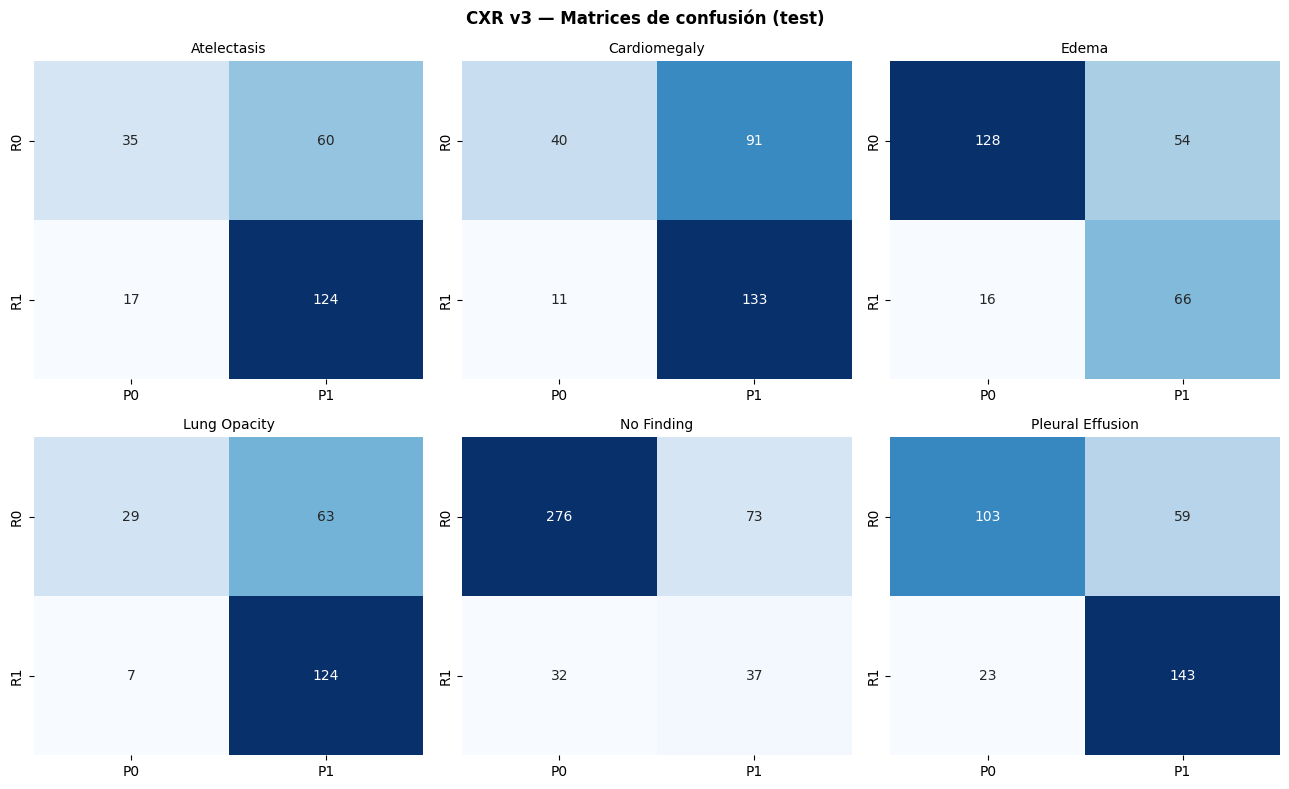

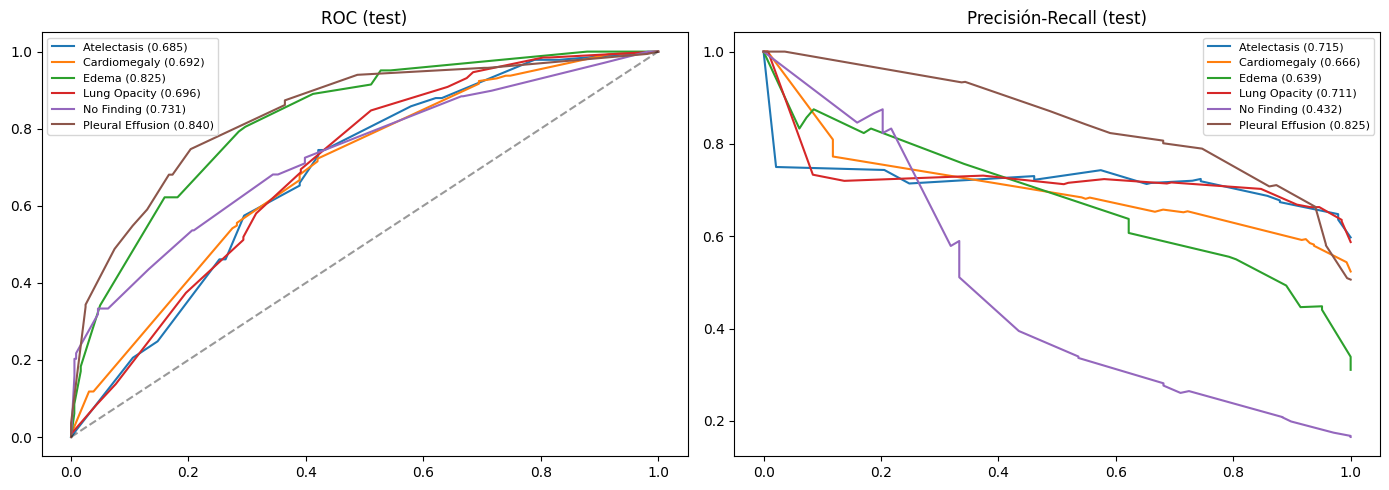

In [11]:
# CELDA 11 · MATRICES DE CONFUSIÓN + ROC/PR + AUC por etiqueta
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle("CXR v3 — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    sns.heatmap(confusion_matrix(yt,yp,labels=[0,1]),annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax,xticklabels=["P0","P1"],yticklabels=["R0","R1"]); ax.set_title(l,fontsize=10)
plt.tight_layout(); plt.savefig(FIG/"confusion_v3.png",dpi=150,bbox_inches="tight"); plt.show()
fig,axes=plt.subplots(1,2,figsize=(14,5))
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    fpr,tpr,_=roc_curve(yt,yp); axes[0].plot(fpr,tpr,label=f"{l} ({M[l]['AUC']:.3f})")
    pr,rc,_=precision_recall_curve(yt,yp); axes[1].plot(rc,pr,label=f"{l} ({M[l]['AP']:.3f})")
axes[0].plot([0,1],[0,1],"k--",alpha=0.4); axes[0].set_title("ROC (test)"); axes[0].legend(fontsize=8)
axes[1].set_title("Precisión-Recall (test)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"roc_pr_v3.png",dpi=150,bbox_inches="tight"); plt.show()

In [12]:
# CELDA 12 · EXPORTAR OOF/val/test PARA EL STACKING (hadm_id, cxr_<label>, cxr_<label>_cal)
def save_predictions(df, raw, cal, name):
    cols={"hadm_id":df["hadm_id"].to_numpy()}
    for j,l in enumerate(LABELS):
        key=l.replace(" ","_"); cols[f"cxr_{key}"]=raw[:,j]; cols[f"cxr_{key}_cal"]=cal[:,j]
    out=pd.DataFrame(cols); p=OUTPUT_DIR/f"cxr_pred_{name}.csv"; out.to_csv(p,index=False); print("   guardado",p.name)
save_predictions(df_train, oof_train, oof_cal, "oof_train")
save_predictions(df_val, val_pred_raw, val_pred, "val")
save_predictions(df_test, test_pred_raw, test_pred, "test")
print("OOF/val/test del CXR v3 exportados.")

   guardado cxr_pred_oof_train.csv
   guardado cxr_pred_val.csv
   guardado cxr_pred_test.csv
OOF/val/test del CXR v3 exportados.


---
## ✅ Conclusión — Módulo CXR v3 (pesado)

**Ensemble de dos backbones** (DenseNet-121@224 con TTA por flip + ResNet-50@512) con cabeza MLP
sobre embeddings + metadatos, **K-fold con bagging multisemilla**, calibración isotónica en VAL y
**OOF sin fuga** para el stacking multimodal.

Adopta el **etiquetado FINAL**, la métrica **AUC-PR con IC bootstrap**, el **kit clínico B1, B2, B3,
B4, B6 y B8**, el **control de calidad de imagen** y la **exclusión de `cxr_view`** como predictor.

### 📌 Para la documentación posterior (recuadros naranjas a redactar con los resultados)
- **¿Compensa el coste?** v3 es con diferencia el modelo más caro del TFM. Si la mejora en AUC-PR
  frente a v2 es de milésimas y los **IC se solapan**, la conclusión honesta es que **no aporta** y
  que el techo del módulo de imagen ya se alcanzó en v2. Es un resultado perfectamente defendible.
- **La imagen debe liderar Atelectasia y Opacidad pulmonar** (§5 EDA: las analíticas rondan el azar
  en esas dos). Si aquí tampoco se separan, el problema es de preprocesado o etiquetado.
- **Efecto de retirar `cxr_view`**: si el rendimiento baja respecto a ejecuciones antiguas, parte de
  aquel resultado venía del atajo asistencial, no de la imagen. **Eso es exactamente lo que se
  quería evitar** y conviene decirlo así en la memoria.
- **Proyección AP/PA**: comprobar si Cardiomegalia rinde muy distinto entre proyecciones (la AP
  magnifica la silueta cardíaca) → discutirlo como **sesgo de espectro**.
- **TTA y bagging**: indicar si aportan por encima del ruido; con val/test pequeños es fácil
  confundir mejora real con varianza.
- **Calibración**: ¿mejora el Brier? Recordar **recalibrar tras la fusión**.
- **Consistencia**: la correlación entre P(*Sin hallazgo*) y max P(patología) debe ser **negativa**.
- **Equidad**: subgrupos con n<60 ⇒ ruido, no inequidad. No concluir sin IC.

